<a href="https://colab.research.google.com/github/ThakurNishant2004/ML-concepts/blob/master/Unsupervised_DB_SCAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
X , y_true = make_blobs(n_samples=500,centers=3,cluster_std=0.6,random_state=42)

In [ ]:
df = pd.DataFrame(X,columns=['Feature1','Feature2'])

<Axes: xlabel='Feature1', ylabel='Feature2'>

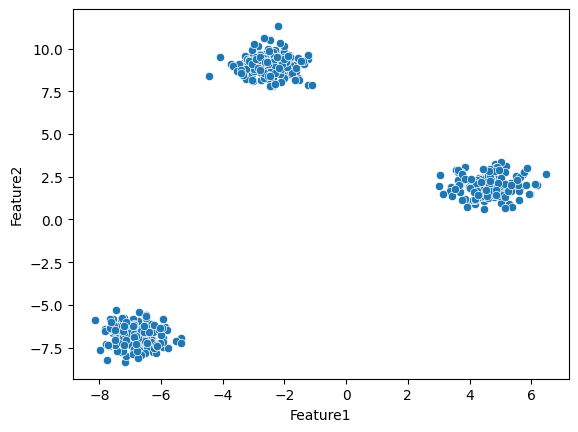

In [ ]:
sns.scatterplot(x='Feature1',y='Feature2',data = df)

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [ ]:
inertia = []
K_range = range(1,11)

In [ ]:
for k in K_range:
  kmeans = KMeans(n_clusters=k,random_state=42)
  kmeans.fit(X_scaled)
  inertia.append(kmeans.inertia_)

In [ ]:
inertia

[1000.0000000000006,
 297.8954141051723,
 11.575484723104985,
 9.752067977356848,
 8.257175272446279,
 6.917577320416797,
 6.334755391595288,
 5.704177177901426,
 5.060234133532074,
 4.7623618981303935]

Text(0.5, 1.0, 'The Elbow Method')

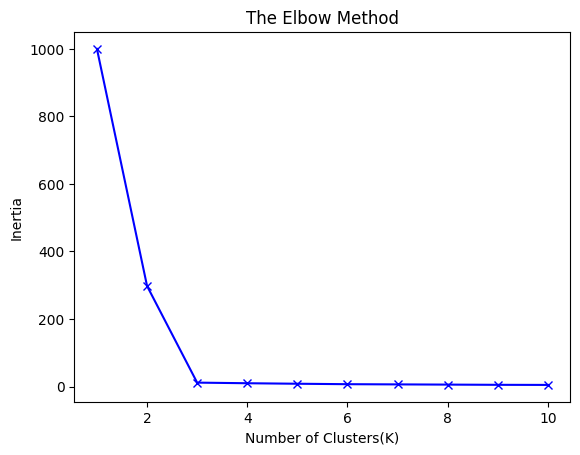

In [ ]:
plt.plot(K_range,inertia,'bx-')
plt.xlabel('Number of Clusters(K)')
plt.ylabel('Inertia')
plt.title('The Elbow Method')

In [ ]:
k_means_final = KMeans(n_clusters=3,random_state=42)
cluster_labels = k_means_final.fit_predict(X_scaled)

In [ ]:
cluster_labels

array([1, 0, 0, 2, 0, 0, 1, 0, 0, 1, 0, 2, 2, 2, 0, 0, 2, 1, 1, 2, 0, 2,
       0, 1, 1, 0, 0, 1, 1, 2, 0, 2, 2, 2, 0, 0, 0, 0, 1, 1, 0, 2, 2, 2,
       2, 0, 0, 0, 0, 1, 1, 2, 1, 1, 0, 2, 2, 1, 0, 1, 1, 2, 0, 1, 0, 1,
       0, 1, 2, 0, 0, 0, 0, 1, 2, 1, 2, 0, 2, 2, 1, 2, 0, 2, 1, 1, 1, 1,
       0, 2, 1, 0, 2, 0, 0, 1, 2, 2, 2, 1, 0, 2, 2, 1, 1, 2, 2, 1, 2, 1,
       1, 1, 1, 1, 1, 0, 2, 1, 0, 1, 2, 2, 0, 0, 1, 0, 2, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 2, 1, 1, 0, 0, 1, 1, 1, 2, 2, 2, 0, 1, 0, 0,
       2, 1, 2, 1, 0, 0, 1, 1, 2, 2, 1, 2, 2, 0, 1, 1, 1, 2, 2, 1, 1, 2,
       2, 0, 0, 0, 2, 1, 2, 2, 1, 1, 2, 0, 2, 1, 1, 1, 1, 1, 2, 0, 2, 2,
       1, 0, 2, 2, 1, 1, 0, 1, 0, 2, 2, 1, 1, 0, 1, 2, 2, 1, 2, 1, 2, 0,
       0, 2, 1, 2, 0, 2, 2, 1, 0, 0, 0, 0, 2, 1, 1, 1, 2, 0, 2, 0, 0, 0,
       2, 2, 1, 1, 0, 2, 2, 0, 2, 2, 2, 2, 0, 2, 1, 2, 1, 2, 2, 2, 1, 2,
       0, 0, 0, 2, 0, 0, 2, 2, 0, 1, 2, 2, 2, 2, 1, 1, 2, 0, 2, 2, 1, 2,
       0, 1, 0, 0, 1, 2, 2, 2, 1, 2, 1, 0, 0, 2, 0,

In [ ]:
df['clusters'] = cluster_labels

<Axes: xlabel='Feature1', ylabel='Feature2'>

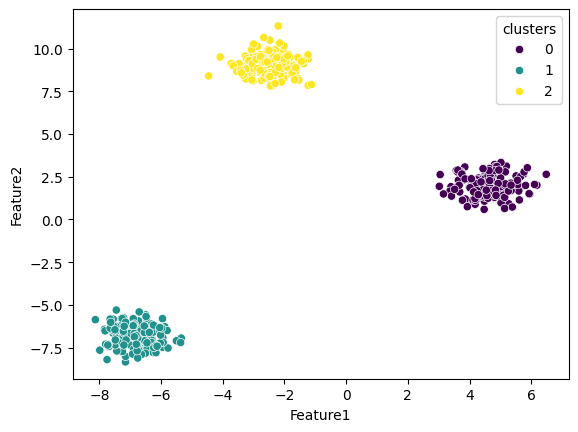

In [ ]:
sns.scatterplot(x='Feature1',y='Feature2',hue='clusters',data=df,palette='viridis')

In [2]:
# DB SCAN

In [3]:
from sklearn.datasets import make_moons

In [4]:
X , y_true = make_moons(n_samples=500, noise=0.05, random_state=42)

In [5]:
from sklearn.cluster import KMeans , DBSCAN

In [6]:
df = pd.DataFrame(X,columns=['feature1','feature2'])

<Axes: xlabel='feature1', ylabel='feature2'>

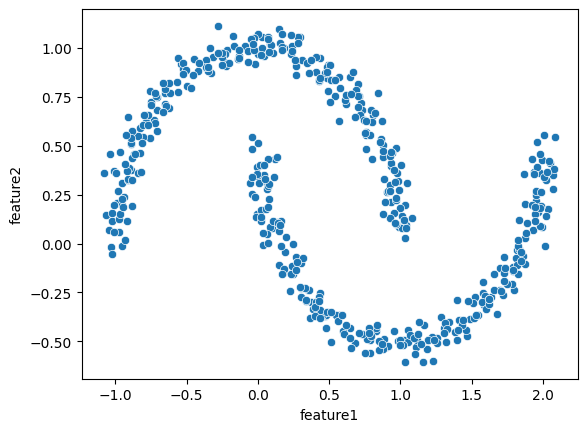

In [7]:
sns.scatterplot(x='feature1',y='feature2',data=df)

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [9]:
kmeans = KMeans(n_clusters=2,random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

In [10]:
df['clusters']= cluster_labels

<Axes: xlabel='feature1', ylabel='feature2'>

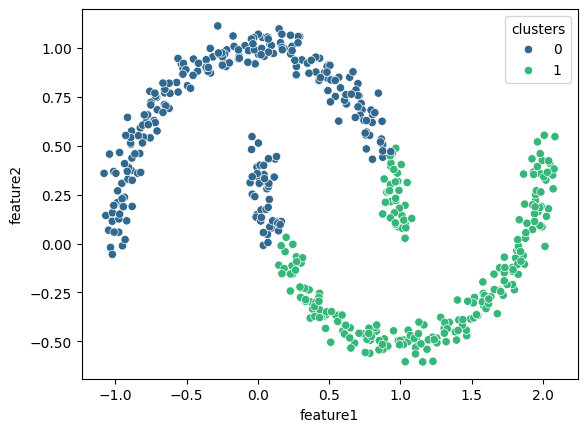

In [13]:
sns.scatterplot(x='feature1',y='feature2',hue='clusters',data=df,palette='viridis')

In [14]:
# DBSCAN

In [15]:
dbscan = DBSCAN(eps=0.3,min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

In [16]:
df_dbscan = df.copy()
df_dbscan['clusters']=dbscan_labels

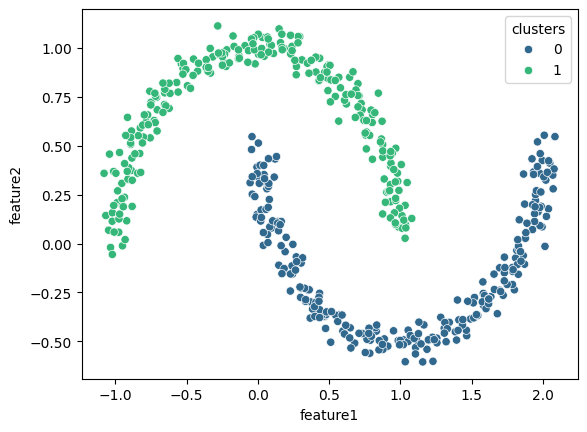

In [19]:
sns.scatterplot(x='feature1',y='feature2',hue='clusters',data=df_dbscan,palette='viridis')
plt.show()